In [1]:
!pip install -q scikit-learn xgboost pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
import joblib
import warnings
import re
import random
from collections import Counter
from typing import Dict, List, Tuple, Any
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Setup complete!")

Setup complete!


In [3]:
# Mount Google Drive and set path
from google.colab import drive
drive.mount('/content/drive')

# Update this path to match where you saved MASTER.csv in your Drive
DATA_PATH = '/content/drive/MyDrive/Master.csv'  # Adjust path as needed

# Verify file exists
import os
if os.path.exists(DATA_PATH):
    print(f"✓ Found data file at: {DATA_PATH}")
else:
    print(f"✗ File not found at: {DATA_PATH}")
    print("\nFiles in MyDrive:")
    !ls "/content/drive/MyDrive/"

Mounted at /content/drive
✓ Found data file at: /content/drive/MyDrive/Master.csv


In [4]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDiscipline distribution:")
print(df['discipline'].value_counts())
print(f"\nClass balance:")
print(df['discipline'].value_counts(normalize=True))

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())

# Sample data
print("\nSample data:")
df.head()

Dataset shape: (26944, 6)

Columns: ['title', 'abstract', 'discipline', 'subfield', 'methodology', 'confidence']

Discipline distribution:
discipline
CS    14910
IS    10460
IT     1574
Name: count, dtype: int64

Class balance:
discipline
CS    0.553370
IS    0.388213
IT    0.058417
Name: proportion, dtype: float64

Missing values:
title          0
abstract       0
discipline     0
subfield       0
methodology    0
confidence     0
dtype: int64

Sample data:


,title,abstract,discipline,subfield,methodology,confidence
0,Developing Secure and Interoperable Health Inf...,Healthcare information systems are going throu...,IS,HIS,QUAL,0.70
1,Security and Privacy of Technologies in Health...,Health information systems (HISs) have immense...,IS,HIS,QUAL,0.80
2,"ZeroTrustBlock: Enhancing Security, Privacy, a...","With the digitization of healthcare, an immens...",IS,HIS,QUANT,0.90
3,Leveraging blockchain for sustainable supply c...,This review examines how blockchain technology...,IS,BPM,QUAL,0.80
4,Artificial Intelligence for Secured Informatio...,The accelerated expansion of the Internet of T...,CS,SE,MIXED,0.85


In [5]:
def preprocess_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Keep alphanumeric, spaces, and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\-]', ' ', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Combine title and abstract for better context
df['combined_text'] = df['title'].fillna('') + ' ' + df['abstract'].fillna('')
df['processed_text'] = df['combined_text'].apply(preprocess_text)

# Remove any rows with empty processed text
df = df[df['processed_text'].str.len() > 10].copy()
print(f"Dataset shape after preprocessing: {df.shape}")

Dataset shape after preprocessing: (26944, 8)


In [6]:
# IMPORTANT: Split BEFORE any augmentation to prevent data leakage
# Using stratified split to maintain class distribution

# First split: separate test set (20%)
X = df['processed_text'].values
y = df['discipline'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

# Second split: separate train and validation from temp (80/20 of remaining = 64/16 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, stratify=y_temp, random_state=RANDOM_SEED
)

print(f"Train set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Verify stratification
print("\nClass distribution in splits:")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = pd.Series(y_split).value_counts(normalize=True).sort_index()
    print(f"{name}: {dist.to_dict()}")

# Save split indices for consistent use across all classifiers
split_indices = {
    'train_indices': np.where(np.isin(X, X_train))[0].tolist(),
    'val_indices': np.where(np.isin(X, X_val))[0].tolist(),
    'test_indices': np.where(np.isin(X, X_test))[0].tolist()
}
joblib.dump(split_indices, 'split_indices_v7.pkl')
print("\nSplit indices saved for consistent use across classifiers!")

Train set size: 17244 (64.0%)
Validation set size: 4311 (16.0%)
Test set size: 5389 (20.0%)

Class distribution in splits:
Train: {'CS': 0.5534098816979819, 'IS': 0.38819299466481094, 'IT': 0.05839712363720714}
Val: {'CS': 0.5532359081419624, 'IS': 0.3883089770354906, 'IT': 0.05845511482254697}
Test: {'CS': 0.5533494154759696, 'IS': 0.3881981814807942, 'IT': 0.05845240304323622}

Split indices saved for consistent use across classifiers!


In [7]:
class TextAugmenter:
    """Conservative text augmentation to prevent overfitting"""

    def __init__(self, augmentation_ratio=0.5):
        self.augmentation_ratio = augmentation_ratio

    def shuffle_sentences(self, text):
        """Randomly shuffle sentences in text"""
        sentences = text.split('.')
        sentences = [s.strip() for s in sentences if s.strip()]
        if len(sentences) > 1:
            random.shuffle(sentences)
            return '. '.join(sentences) + '.'
        return text

    def paraphrase_simple(self, text):
        """Simple paraphrasing by replacing common phrases"""
        replacements = {
            'study': 'research',
            'research': 'study',
            'method': 'approach',
            'approach': 'method',
            'shows': 'demonstrates',
            'demonstrates': 'shows',
            'uses': 'employs',
            'employs': 'uses',
            'analysis': 'examination',
            'examination': 'analysis'
        }

        words = text.split()
        for i, word in enumerate(words):
            if word.lower() in replacements and random.random() < 0.3:
                words[i] = replacements[word.lower()]
        return ' '.join(words)

    def augment_dataset(self, X, y):
        """Augment training data only"""
        augmented_X = list(X)
        augmented_y = list(y)

        # Count samples per class
        class_counts = Counter(y)
        max_count = max(class_counts.values())

        for class_label, count in class_counts.items():
            # Calculate how many samples to add (reduced augmentation)
            target_count = int(count + (max_count - count) * self.augmentation_ratio)
            samples_to_add = target_count - count

            if samples_to_add > 0:
                # Get indices of this class
                class_indices = [i for i, label in enumerate(y) if label == class_label]

                for _ in range(samples_to_add):
                    # Randomly select a sample to augment
                    idx = random.choice(class_indices)
                    original_text = X[idx]

                    # Apply augmentation
                    if random.random() < 0.5:
                        augmented_text = self.shuffle_sentences(original_text)
                    else:
                        augmented_text = self.paraphrase_simple(original_text)

                    augmented_X.append(augmented_text)
                    augmented_y.append(class_label)

        return np.array(augmented_X), np.array(augmented_y)

# Apply augmentation ONLY to training data
augmenter = TextAugmenter(augmentation_ratio=0.5)
X_train_aug, y_train_aug = augmenter.augment_dataset(X_train, y_train)

print(f"Original training samples: {len(X_train)}")
print(f"Augmented training samples: {len(X_train_aug)}")
print(f"Augmentation increase: {(len(X_train_aug) - len(X_train)) / len(X_train) * 100:.1f}%")

# Check new class distribution
print("\nAugmented training set class distribution:")
print(pd.Series(y_train_aug).value_counts())

Original training samples: 17244
Augmented training samples: 22936
Augmentation increase: 33.0%

Augmented training set class distribution:
CS    9543
IS    8118
IT    5275
Name: count, dtype: int64


In [8]:
class OptimizedFeatureExtractor:
    """Optimized feature extraction with reduced dimensionality"""

    def __init__(self):
        # Reduced max_features for each vectorizer
        self.vectorizers = {
            'unigram_bigram': TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=2000,  # Reduced from 3000
                min_df=3,
                max_df=0.9,
                sublinear_tf=True
            ),
            'char_ngram': TfidfVectorizer(
                analyzer='char',
                ngram_range=(3, 5),
                max_features=1000,  # Reduced from 2000
                min_df=3,
                max_df=0.9
            )
        }
        self.is_fitted = False

    def fit(self, texts):
        """Fit vectorizers on training data only"""
        for name, vectorizer in self.vectorizers.items():
            vectorizer.fit(texts)
        self.is_fitted = True
        return self

    def transform(self, texts):
        """Transform texts to features"""
        if not self.is_fitted:
            raise ValueError("Feature extractor must be fitted first")

        features = []
        for name, vectorizer in self.vectorizers.items():
            features.append(vectorizer.transform(texts))

        # Combine all features
        from scipy.sparse import hstack
        return hstack(features)

    def fit_transform(self, texts):
        """Fit and transform in one step"""
        self.fit(texts)
        return self.transform(texts)

    def get_feature_names(self):
        """Get all feature names"""
        names = []
        for name, vectorizer in self.vectorizers.items():
            names.extend([f"{name}_{n}" for n in vectorizer.get_feature_names_out()])
        return names

# Create and fit feature extractor on TRAINING DATA ONLY
feature_extractor = OptimizedFeatureExtractor()

print("Fitting feature extractor on training data...")
X_train_features = feature_extractor.fit_transform(X_train_aug)
X_val_features = feature_extractor.transform(X_val)
X_test_features = feature_extractor.transform(X_test)

print(f"\nFeature dimensions:")
print(f"Training: {X_train_features.shape}")
print(f"Validation: {X_val_features.shape}")
print(f"Test: {X_test_features.shape}")
print(f"Total features: {X_train_features.shape[1]}")

Fitting feature extractor on training data...

Feature dimensions:
Training: (22936, 3000)
Validation: (4311, 3000)
Test: (5389, 3000)
Total features: 3000


In [9]:
# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_aug)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f"Classes: {label_encoder.classes_}")

# Define models to evaluate
models = {
    'xgboost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',
        n_jobs=-1,
        random_state=RANDOM_SEED,
        early_stopping_rounds=20,
        eval_metric='mlogloss'
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),
    'logistic_regression': LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='saga',
        n_jobs=-1,
        random_state=RANDOM_SEED
    )
}

# Train models and evaluate
results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    if model_name == 'xgboost':
        # XGBoost with early stopping
        model.fit(
            X_train_features, y_train_encoded,
            eval_set=[(X_val_features, y_val_encoded)],
            verbose=False
        )
    else:
        # Other models
        model.fit(X_train_features, y_train_encoded)

    # Evaluate on validation set
    val_pred = model.predict(X_val_features)
    val_acc = accuracy_score(y_val_encoded, val_pred)

    # Store results
    results[model_name] = {
        'model': model,
        'val_accuracy': val_acc,
        'val_predictions': val_pred
    }

    print(f"{model_name} validation accuracy: {val_acc:.4f}")

# Select best model based on validation accuracy
best_model_name = max(results, key=lambda x: results[x]['val_accuracy'])
best_model = results[best_model_name]['model']
print(f"\nBest model: {best_model_name}")

Classes: ['CS' 'IS' 'IT']

Training xgboost...
xgboost validation accuracy: 0.9200

Training random_forest...
random_forest validation accuracy: 0.8722

Training logistic_regression...
logistic_regression validation accuracy: 0.9132

Best model: xgboost


In [11]:
# Perform cross-validation on the best model type
print(f"Performing 5-fold cross-validation on {best_model_name}...")

# Create a new model instance without early stopping for CV
if best_model_name == 'xgboost':
    # XGBoost without early stopping for CV
    cv_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',
        n_jobs=-1,
        random_state=RANDOM_SEED,
        # Remove early_stopping_rounds and eval_metric for CV
    )
else:
    # Other models
    cv_model = models[best_model_name].__class__(**models[best_model_name].get_params())

# Use only training data for CV (not augmented to get realistic estimate)
cv_scores = cross_val_score(
    cv_model,
    feature_extractor.transform(X_train),
    label_encoder.transform(y_train),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='accuracy',
    n_jobs=-1
)

print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Also calculate CV scores for all models for comparison
print("\n5-Fold CV comparison for all models:")
for model_name in ['xgboost', 'random_forest', 'logistic_regression']:
    if model_name == 'xgboost':
        temp_model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            objective='multi:softprob',
            n_jobs=-1,
            random_state=RANDOM_SEED
        )
    elif model_name == 'random_forest':
        temp_model = RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            n_jobs=-1,
            random_state=RANDOM_SEED
        )
    else:
        temp_model = LogisticRegression(
            max_iter=1000,
            C=1.0,
            solver='saga',
            n_jobs=-1,
            random_state=RANDOM_SEED
        )

    scores = cross_val_score(
        temp_model,
        feature_extractor.transform(X_train),
        label_encoder.transform(y_train),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring='accuracy',
        n_jobs=-1
    )
    print(f"{model_name}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Performing 5-fold cross-validation on xgboost...

Cross-validation scores: [0.91939693 0.91214845 0.91504784 0.91446796 0.92546404]
Mean CV accuracy: 0.9173 (+/- 0.0094)

5-Fold CV comparison for all models:
xgboost: 0.9173 (+/- 0.0094)
random_forest: 0.8729 (+/- 0.0069)
logistic_regression: 0.9243 (+/- 0.0036)


Test set accuracy: 0.9232

Classification Report:
              precision    recall  f1-score   support

          CS       0.94      0.95      0.95      2982
          IS       0.92      0.93      0.93      2092
          IT       0.72      0.61      0.66       315

    accuracy                           0.92      5389
   macro avg       0.86      0.83      0.85      5389
weighted avg       0.92      0.92      0.92      5389



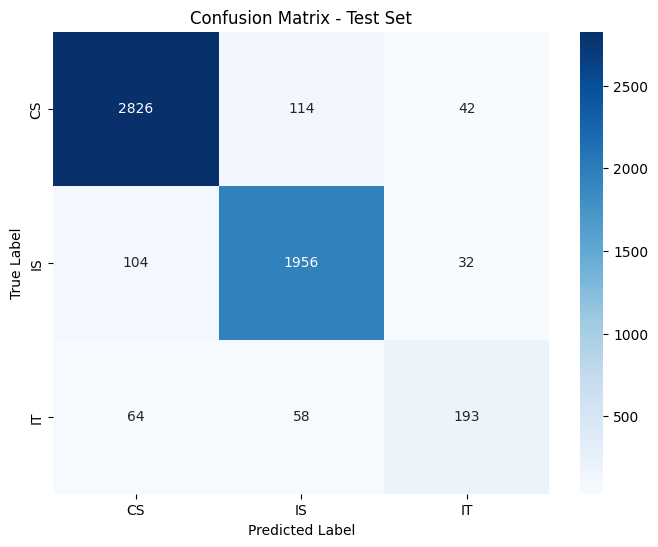


CS accuracy: 0.9477

IS accuracy: 0.9350

IT accuracy: 0.6127


In [12]:
# Evaluate best model on test set
test_pred = best_model.predict(X_test_features)
test_pred_proba = best_model.predict_proba(X_test_features)

# Get predictions in original labels
test_pred_labels = label_encoder.inverse_transform(test_pred)

# Calculate metrics
test_accuracy = accuracy_score(y_test, test_pred_labels)
print(f"Test set accuracy: {test_accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, test_pred_labels))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Per-class accuracy
for i, class_name in enumerate(label_encoder.classes_):
    class_mask = y_test == class_name
    class_acc = accuracy_score(y_test[class_mask], test_pred_labels[class_mask])
    print(f"\n{class_name} accuracy: {class_acc:.4f}")

In [13]:
# Analyze misclassifications
misclassified_mask = y_test != test_pred_labels
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassifications: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_test)*100:.2f}%)")

# Confusion analysis
confusion_pairs = Counter(zip(y_test[misclassified_mask], test_pred_labels[misclassified_mask]))
print("\nMost common confusions (true_label -> predicted_label):")
for (true_label, pred_label), count in confusion_pairs.most_common(5):
    print(f"{true_label} -> {pred_label}: {count} times")

# Sample misclassified examples
print("\nSample misclassified abstracts:")
for i in misclassified_indices[:3]:
    print(f"\nTrue: {y_test[i]}, Predicted: {test_pred_labels[i]}")
    print(f"Confidence: {test_pred_proba[i].max():.3f}")
    print(f"Text preview: {X_test[i][:200]}...")

Total misclassifications: 414 (7.68%)

Most common confusions (true_label -> predicted_label):
CS -> IS: 114 times
IS -> CS: 104 times
IT -> CS: 64 times
IT -> IS: 58 times
CS -> IT: 42 times

Sample misclassified abstracts:

True: IS, Predicted: CS
Confidence: 0.744
Text preview: a drug combination rescues frataxin-dependent neural and cardiac pathophysiology in fa models friedreich s ataxia fa is an inherited multisystemic neuro- and cardio-degenerative disorder. seventy-four...

True: CS, Predicted: IS
Confidence: 0.567
Text preview: a secure blockchain framework for storing historical text a case study of the holy hadith. paper titled a secure blockchain framework for storing historical text a case study of the holy hadith. publi...

True: CS, Predicted: IS
Confidence: 0.835
Text preview: demo sectorx, an en-route atc simulator for ai-based decision support to air traffic controllers a case study in the mahalo project. paper titled demo sectorx, an en-route atc simulator for ai-bas

In [14]:
class DisciplineClassifierPipeline:
    """Production-ready pipeline for discipline classification"""

    def __init__(self):
        self.feature_extractor = None
        self.model = None
        self.label_encoder = None
        self.is_fitted = False

    def fit(self, X, y):
        """Train the complete pipeline"""
        # Initialize components
        self.feature_extractor = OptimizedFeatureExtractor()
        self.label_encoder = LabelEncoder()

        # Encode labels
        y_encoded = self.label_encoder.fit_transform(y)

        # Extract features
        X_features = self.feature_extractor.fit_transform(X)

        # Train model (using best model configuration)
        self.model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            objective='multi:softprob',
            n_jobs=-1,
            random_state=RANDOM_SEED
        )
        self.model.fit(X_features, y_encoded)

        self.is_fitted = True
        return self

    def predict(self, X):
        """Predict disciplines for new texts"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted first")

        # Extract features
        X_features = self.feature_extractor.transform(X)

        # Predict
        predictions = self.model.predict(X_features)

        # Convert to labels
        return self.label_encoder.inverse_transform(predictions)

    def predict_proba(self, X):
        """Get prediction probabilities"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted first")

        X_features = self.feature_extractor.transform(X)
        proba = self.model.predict_proba(X_features)

        # Return as dictionary with class labels
        results = []
        for p in proba:
            result = {}
            for i, class_label in enumerate(self.label_encoder.classes_):
                result[class_label] = float(p[i])
            results.append(result)

        return results

    def classify_single(self, title, abstract):
        """Classify a single paper"""
        # Preprocess
        combined_text = f"{title} {abstract}"
        processed_text = preprocess_text(combined_text)

        # Predict
        prediction = self.predict([processed_text])[0]
        proba = self.predict_proba([processed_text])[0]

        return {
            'discipline': prediction,
            'confidence': proba[prediction],
            'probabilities': proba
        }

    def save(self, path):
        """Save the pipeline"""
        joblib.dump({
            'feature_extractor': self.feature_extractor,
            'model': self.model,
            'label_encoder': self.label_encoder
        }, path)

    def load(self, path):
        """Load a saved pipeline"""
        components = joblib.load(path)
        self.feature_extractor = components['feature_extractor']
        self.model = components['model']
        self.label_encoder = components['label_encoder']
        self.is_fitted = True
        return self

# Create and train production pipeline
print("Training production pipeline...")
pipeline = DisciplineClassifierPipeline()
pipeline.fit(X_train_aug, y_train_aug)

# Test the pipeline
test_title = "Deep Learning for Computer Vision"
test_abstract = "This paper presents a novel convolutional neural network architecture for image classification..."
result = pipeline.classify_single(test_title, test_abstract)
print(f"\nTest classification:")
print(f"Discipline: {result['discipline']}")
print(f"Confidence: {result['confidence']:.3f}")
print(f"All probabilities: {result['probabilities']}")

Training production pipeline...

Test classification:
Discipline: CS
Confidence: 0.999
All probabilities: {np.str_('CS'): 0.9992528557777405, np.str_('IS'): 0.00010752424714155495, np.str_('IT'): 0.0006395763484761119}


In [15]:
# Create artifacts directory
os.makedirs('discipline_classifier_v7', exist_ok=True)

# Save the production pipeline
pipeline_path = 'discipline_classifier_v7/discipline_pipeline_v7.pkl'
pipeline.save(pipeline_path)
print(f"Pipeline saved to {pipeline_path}")

# Save individual components for analysis
artifacts = {
    'feature_extractor': feature_extractor,
    'model': best_model,
    'label_encoder': label_encoder,
    'training_config': {
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'augmentation_ratio': 0.5,
        'feature_count': X_train_features.shape[1],
        'best_model': best_model_name,
        'test_accuracy': test_accuracy,
        'cv_mean_accuracy': cv_scores.mean(),
        'timestamp': datetime.now().isoformat()
    }
}

joblib.dump(artifacts, 'discipline_classifier_v7/artifacts_v7.pkl')

# Save performance metrics
with open('discipline_classifier_v7/metrics_v7.txt', 'w') as f:
    f.write(f"Discipline Classifier v7.0 Performance Metrics\n")
    f.write(f"=" * 50 + "\n\n")
    f.write(f"Training date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Dataset size: {len(df)}\n")
    f.write(f"Train/Val/Test split: {len(X_train)}/{len(X_val)}/{len(X_test)}\n")
    f.write(f"Augmented training size: {len(X_train_aug)}\n")
    f.write(f"Feature count: {X_train_features.shape[1]}\n")
    f.write(f"Best model: {best_model_name}\n\n")
    f.write(f"Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}\n")
    f.write(f"Test accuracy: {test_accuracy:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, test_pred_labels))

print("\nAll artifacts saved successfully!")
print(f"\nFinal test accuracy: {test_accuracy:.4f}")
print(f"Expected production accuracy: {cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}")

Pipeline saved to discipline_classifier_v7/discipline_pipeline_v7.pkl

All artifacts saved successfully!

Final test accuracy: 0.9232
Expected production accuracy: 0.9173 ± 0.0094


In [16]:
# Load and use the saved pipeline
loaded_pipeline = DisciplineClassifierPipeline()
loaded_pipeline.load('discipline_classifier_v7/discipline_pipeline_v7.pkl')

# Example papers to classify
test_papers = [
    {
        'title': 'Blockchain-based Security Framework for IoT Networks',
        'abstract': 'This research proposes a novel security architecture using blockchain technology to secure Internet of Things devices...'
    },
    {
        'title': 'Digital Transformation in Healthcare Organizations',
        'abstract': 'This study examines how hospitals are implementing digital transformation strategies to improve patient care...'
    },
    {
        'title': 'Implementing DevOps Practices in Cloud Environments',
        'abstract': 'We present best practices for implementing continuous integration and deployment pipelines in AWS and Azure...'
    }
]

print("Example classifications:\n")
for paper in test_papers:
    result = loaded_pipeline.classify_single(paper['title'], paper['abstract'])
    print(f"Title: {paper['title']}")
    print(f"Predicted: {result['discipline']} (confidence: {result['confidence']:.3f})")
    print(f"All probabilities: {result['probabilities']}")
    print("-" * 50)

Example classifications:

Title: Blockchain-based Security Framework for IoT Networks
Predicted: CS (confidence: 0.856)
All probabilities: {np.str_('CS'): 0.8557249903678894, np.str_('IS'): 0.0545886866748333, np.str_('IT'): 0.08968628942966461}
--------------------------------------------------
Title: Digital Transformation in Healthcare Organizations
Predicted: IS (confidence: 0.997)
All probabilities: {np.str_('CS'): 0.001707819988951087, np.str_('IS'): 0.9973171353340149, np.str_('IT'): 0.0009750423487275839}
--------------------------------------------------
Title: Implementing DevOps Practices in Cloud Environments
Predicted: IT (confidence: 0.995)
All probabilities: {np.str_('CS'): 0.002404504455626011, np.str_('IS'): 0.0021652234718203545, np.str_('IT'): 0.9954302310943604}
--------------------------------------------------


In [17]:
# Download the trained model and artifacts
from google.colab import files
import zipfile
import os

print("Preparing files for download...")

# Create a zip file with all artifacts
with zipfile.ZipFile('discipline_classifier_v7.zip', 'w') as zipf:
    # Add all files from the classifier directory
    for root, dirs, files_in_dir in os.walk('discipline_classifier_v7'):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path)
            zipf.write(file_path, arcname)

    # Also add the split indices file
    if os.path.exists('split_indices_v7.pkl'):
        zipf.write('split_indices_v7.pkl')

print("Files included in download:")
with zipfile.ZipFile('discipline_classifier_v7.zip', 'r') as zipf:
    for name in zipf.namelist():
        print(f"  - {name}")

# Download the zip file
files.download('discipline_classifier_v7.zip')

print("\n✓ Download started!")
print("\nTo use the model later:")
print("1. Upload discipline_classifier_v7.zip to your Colab/environment")
print("2. Extract: !unzip discipline_classifier_v7.zip")
print("3. Load: pipeline.load('discipline_classifier_v7/discipline_pipeline_v7.pkl')")

Preparing files for download...
Files included in download:
  - discipline_classifier_v7/discipline_pipeline_v7.pkl
  - discipline_classifier_v7/metrics_v7.txt
  - discipline_classifier_v7/artifacts_v7.pkl
  - split_indices_v7.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download started!

To use the model later:
1. Upload discipline_classifier_v7.zip to your Colab/environment
2. Extract: !unzip discipline_classifier_v7.zip
3. Load: pipeline.load('discipline_classifier_v7/discipline_pipeline_v7.pkl')


In [18]:
!cp -r discipline_classifier_v7 "/content/drive/MyDrive/"
!cp split_indices_v7.pkl "/content/drive/MyDrive/"

print("✓ Files saved to your Google Drive!")


✓ Files saved to your Google Drive!
